<a href="https://colab.research.google.com/github/jennake/Astro100-Final-Project/blob/main/FinalProjectFAST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imports:

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
import glob
import warnings
warnings.filterwarnings("ignore")
from matplotlib.gridspec import GridSpec
import pandas as pd
from scipy.signal import find_peaks

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os

Mounted at /content/drive


### Data loading

In [3]:
import glob
dir = 'drive/MyDrive/ASTRO 100/FAST/2025.0318'
fast1 = glob.glob(dir+"/0067.NGC4038.fits")
fast2 = glob.glob(dir+"/0065.NGC4038.fits")
fast3 = glob.glob(dir+"/0064.NGC4038.fits")

In [4]:
bias_list = glob.glob(dir+"/*BIAS*.fits")

science_list1 = glob.glob(dir+"/0067.NGC4038.fits")

flat_list = glob.glob(dir+"/*FLAT*.fits")

lamp_list = glob.glob(dir+"/*COMP*.fits")

print(bias_list)
print(flat_list)
print(science_list1)
print(lamp_list)


['drive/MyDrive/ASTRO 100/FAST/2025.0318/0001.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0005.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0004.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0007.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0006.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0003.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0002.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0008.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0010.BIAS.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0009.BIAS.fits']
['drive/MyDrive/ASTRO 100/FAST/2025.0318/0012.FLAT.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0017.FLAT.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0014.FLAT.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0011.FLAT.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0016.FLAT.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0018.FLAT.fits', 'drive/MyDrive/ASTRO 100/FAST/2025.0318/0013.FLAT.fits', 'drive/MyDrive/ASTRO 100/FAST

### Creating Master Bias and Master Flats

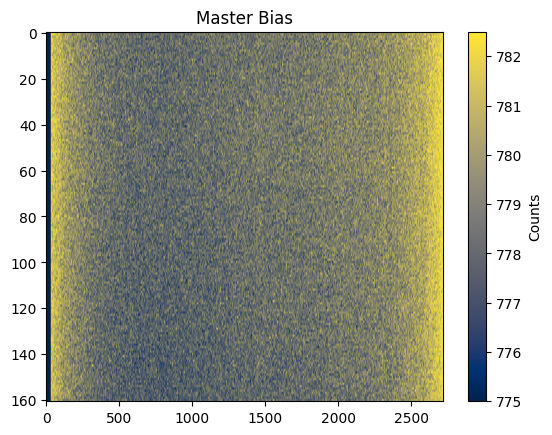

In [5]:
master_bias = []

for i in bias_list:
    data = fits.getdata(i)
    master_bias.append(data[None])  # new axis for stacking

master_bias = np.concatenate(master_bias, axis=0)  # stack all bias frames
master_bias = np.median(master_bias, axis=0)
     # take median to reduce noise

plt.imshow(master_bias,
           vmax=np.percentile(master_bias, 90),
           vmin=np.percentile(master_bias, 10),
           aspect='auto',
           cmap='cividis')
plt.title("Master Bias")
plt.colorbar(label='Counts')
plt.show()

In [6]:
master_flat = []
for m in flat_list:
    data = fits.getdata(m)          # Read FITS file
    data = data - master_bias       # Subtract master bias at easch step
    master_flat.append(data[None])  # Add to list with new axis

master_flat = np.concatenate(master_flat, axis=0)  # Combine all flats
master_flat = np.median(master_flat, axis=0)

In [7]:
science = fits.getdata(science_list1[0])
processed1 = (science - master_bias) / master_flat

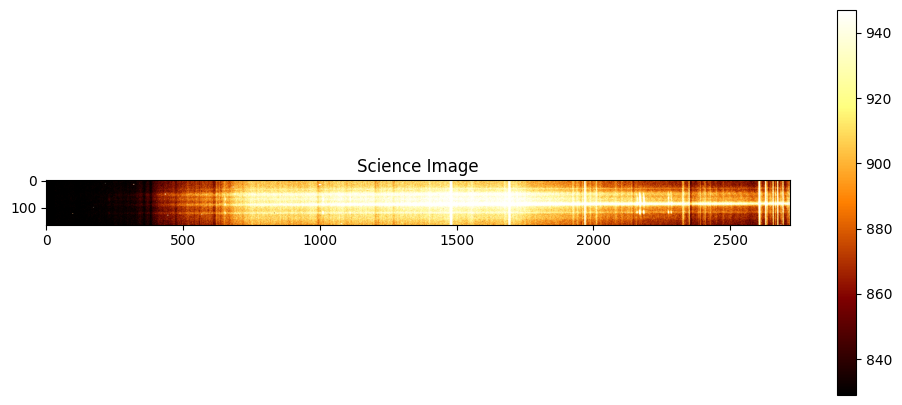

In [24]:
plt.figure(figsize=(12,5))
plt.imshow(science, vmax=np.percentile(science, 90),
           vmin=np.percentile(science, 10), cmap='afmhot')
plt.title('Science Image')
plt.colorbar()

plt.savefig('science_image.png', dpi=300, bbox_inches='tight')
plt.show()


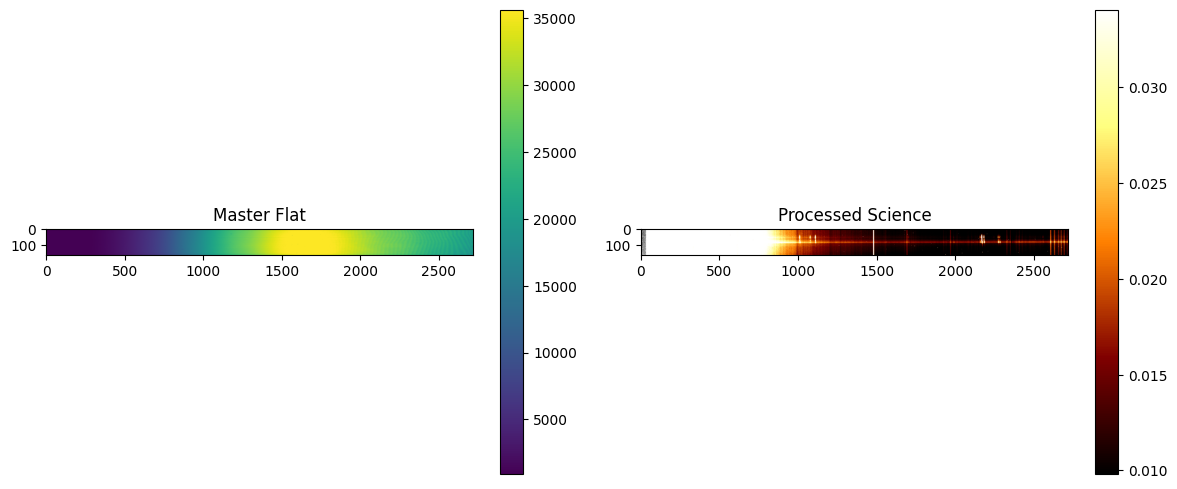

In [25]:
# For master flat
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.imshow(master_flat, vmax=np.percentile(master_flat, 90),
           vmin=np.percentile(master_flat, 10), cmap='viridis')
plt.title('Master Flat')
plt.colorbar()

# For processed science image
plt.subplot(122)
plt.imshow(processed1, vmax=np.percentile(processed1, 70),
           vmin=np.percentile(processed1, 20), cmap='afmhot')
plt.title('Processed Science')
plt.colorbar()
plt.tight_layout()

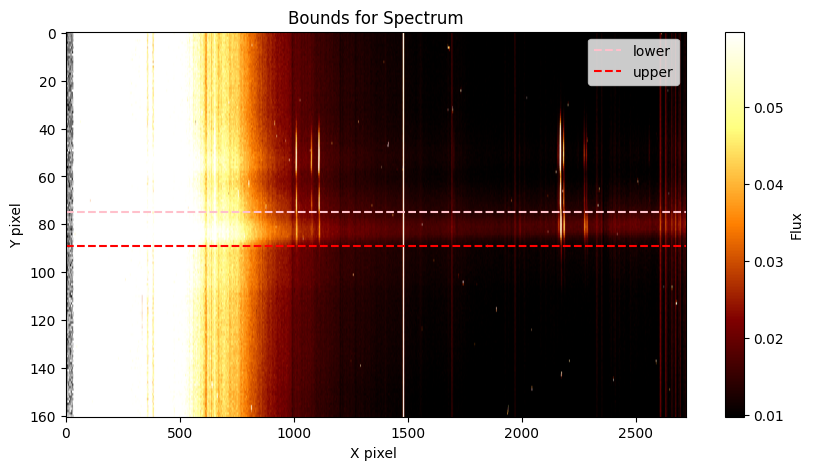

In [26]:
plt.figure(figsize=(10, 5))
plt.imshow(processed1, aspect='auto', cmap='afmhot',
           vmin=np.percentile(processed1, 20), vmax=np.percentile(processed1, 80))
plt.axhline(75, color='pink', linestyle='--', label='lower')
plt.axhline(89, color='red', linestyle='--', label='upper')
plt.legend()
plt.title("Bounds for Spectrum")
plt.xlabel("X pixel ")
plt.ylabel("Y pixel")
plt.colorbar(label='Flux')
plt.savefig('processedscience_image.png', dpi=300, bbox_inches='tight')
plt.show()

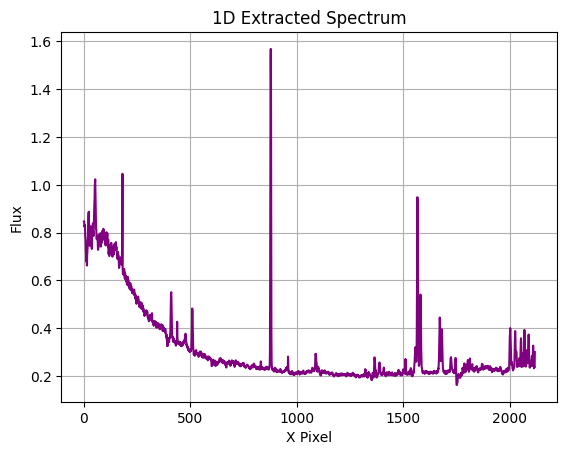

In [27]:
spectrum_1d_cropped = np.sum(processed1[75:89, 600:], axis=0)

plt.plot(spectrum_1d_cropped, color = 'purple')
plt.title("1D Extracted Spectrum")
plt.xlabel("X Pixel")
plt.ylabel("Flux")
plt.grid()
plt.savefig('1dspectrum1_image.png', dpi=300, bbox_inches='tight')
plt.show()

### Wavelength Calibration

In [ ]:
# Using wavelength solution provided:

spectrum = spectrum_1d_cropped
pixels = np.arange(len(spectrum))
poly = [-1.68082138e-07,  6.07623032e-04, 8.74859881e-01, 3.55690966e+03]
g = np.poly1d(poly)
wavelengths = g(pixels)

print(wavelengths[:10])

[3556.90966    3557.78512734 3558.66180891 3559.53970371 3560.41881074
 3561.29912897 3562.18065741 3563.06339504 3563.94734086 3564.83249386]


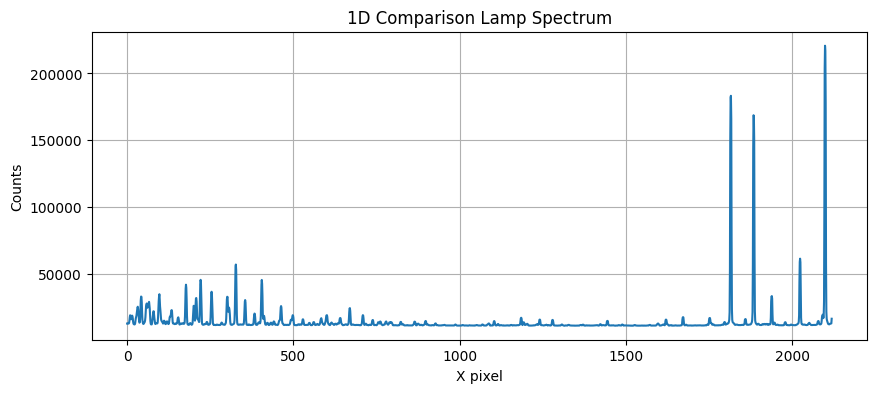

In [ ]:
# Load comparison lamp
lamp_data = fits.getdata('drive/MyDrive/ASTRO 100/FAST/2025.0318/0066.COMP.fits') # 66 or 68?

# Crop and sum rows to extract 1D
lamp_1d = np.sum(lamp_data[75:89, 600:], axis=0)

# Plot to check
plt.figure(figsize=(10, 4))
plt.plot(lamp_1d)
plt.title('1D Comparison Lamp Spectrum')
plt.xlabel('X pixel')
plt.ylabel('Counts')
plt.grid()
plt.show()


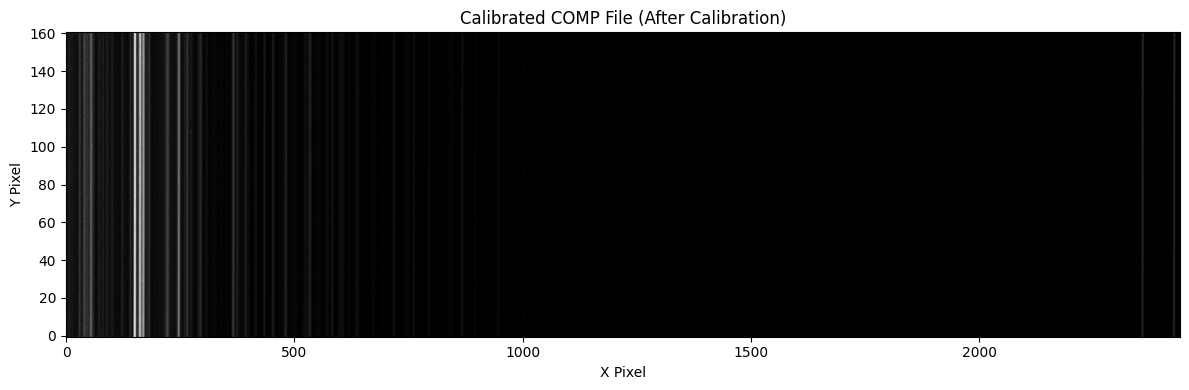

In [ ]:
# Define the directory and specific file
directory = 'drive/MyDrive/ASTRO 100/FAST/2025.0318'
#comp_file = '0043.COMP.fits'  # Specify the COMP file you want to process

lamp_data = '0066.COMP.fits'

# Load the COMP file (before calibration)
comp_file_path = os.path.join(directory, lamp_data)
with fits.open(comp_file_path) as hdul:
    comp_data_raw = hdul[0].data


master_flat = master_flat[:, 30:2500]
master_bias = master_bias[:, 30:2500]

# Trim the raw data (same trimming as for bias and flat)
comp_data_trimmed = comp_data_raw[:, 30:2500]

# Normalize and subtract bias (using combined bias data)
bias_subtracted_comp = comp_data_trimmed - master_bias

# Trim both the bias-subtracted COMP data and the normalized flat to match the smaller size
min_width = min(bias_subtracted_comp.shape[1], master_flat.shape[1])

bias_subtracted_comp_trimmed = bias_subtracted_comp[:, 30:2500]

normalized_flat_trimmed = master_flat[:, 30:2500]

# Apply flat correction (normalize by combined flat)
calibrated_comp = bias_subtracted_comp_trimmed / normalized_flat_trimmed

# Plot the raw, trimmed, and calibrated COMP image
fig, axs = plt.subplots(1, 1, figsize=(12, 4))

# Display the calibrated COMP file
axs.imshow(calibrated_comp, cmap='gray', origin='lower', aspect='auto')
axs.set_title('Calibrated COMP File (After Calibration)')
axs.set_xlabel('X Pixel')
axs.set_ylabel('Y Pixel')

plt.tight_layout()
plt.show()

# Create a 1D spectrum by summing over the spatial dimension (Y-axis)
comp_spectrum_1d = np.sum(calibrated_comp, axis=0)

In [15]:
poly = [-1.68082138e-07,  6.07623032e-04, 8.74859881e-01, 3.55690966e+03]
g = np.poly1d(poly)
pixels = np.arange(len(data[0]))
wavelengths = g(pixels)

In [ ]:
from numpy.polynomial import Polynomial
from scipy.signal import find_peaks

peaks, properties = find_peaks(comp_spectrum_1d)

# Sort peaks by intensity and select the 10 most intense peaks
peak_intensities = properties['peak_heights'] = comp_spectrum_1d[peaks]
top_peaks_idx = np.argsort(peak_intensities)[-10:]  # Indices of the 10 highest peaks
top_peaks = peaks[top_peaks_idx]  # Pixel positions of the 10 highest peaks
top_peaks_intensity = comp_spectrum_1d[top_peaks]  # Intensities of the 10 highest peaks

sorted_peak_pixels = np.sort(top_peaks)
sorted_known_wavelengths = np.sort(wavelengths)

print(len(sorted_known_wavelengths))
print(len(sorted_peak_pixels))

2720
10


Text(0.5, 1.0, '1D Comparison Lamp Spectrum')

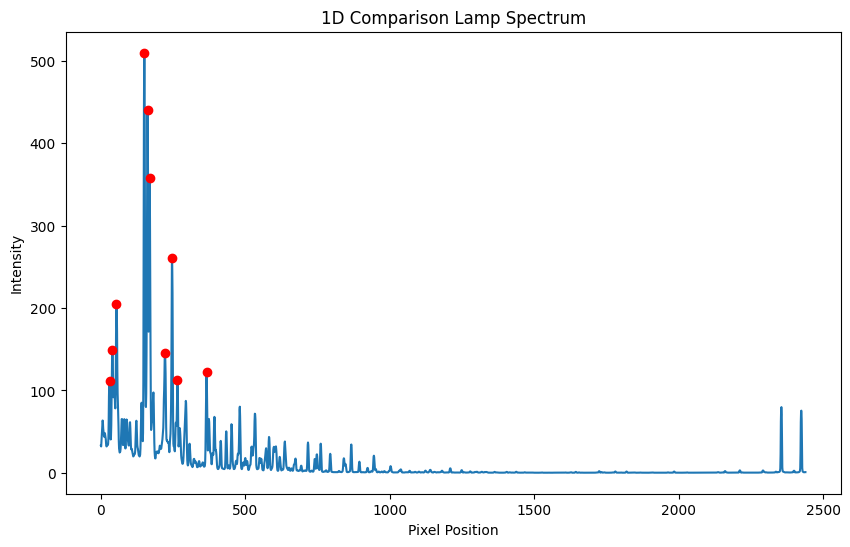

In [ ]:
# Plot the 1D comparison spectrum with the 10 most intense peaks marked
plt.figure(figsize=(10, 6))
plt.plot(comp_spectrum_1d, label='Comparison Spectrum')
plt.plot(top_peaks, top_peaks_intensity, 'ro', label='Top 10 Intense Peaks')
plt.xlabel('Pixel Position')
plt.ylabel('Intensity')
plt.title('1D Comparison Lamp Spectrum')

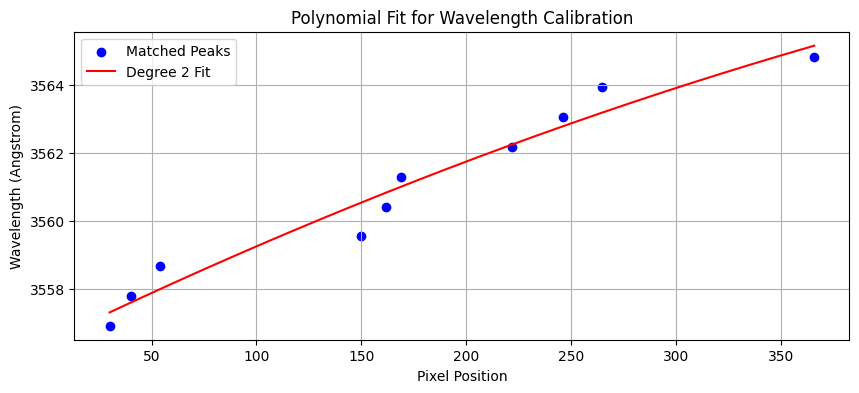

In [ ]:
# 3. Fit a polynomial (linear or quadratic depending on distortion)
# First, slice your known wavelengths down to match
sorted_known_wavelengths = sorted_known_wavelengths[:10]  # or the same length as sorted_peak_pixels

fit_poly = Polynomial.fit(sorted_peak_pixels, sorted_known_wavelengths, deg=2)  # Use deg=2 if needed

# 4. Apply the mapping to convert pixels to wavelengths
pixel_indices = np.arange(len(comp_spectrum_1d))
calibrated_wavelengths = fit_poly(pixel_indices)

plt.figure(figsize=(10, 4))

# Scatter of known data points
plt.scatter(sorted_peak_pixels, sorted_known_wavelengths, color='blue', label='Matched Peaks')

# Polynomial fit curve
x_fit = np.linspace(min(sorted_peak_pixels), max(sorted_peak_pixels), 1000)
y_fit = fit_poly(x_fit)
plt.plot(x_fit, y_fit, color='red', label=f'Degree {fit_poly.degree()} Fit')

plt.xlabel("Pixel Position")
plt.ylabel("Wavelength (Angstrom)")
plt.title("Polynomial Fit for Wavelength Calibration")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def plot_wavelength_pixel_solution(
    spectrum, pixel_positions, wavelength_values, wavelength_labels = wavelength_label, annotate=True,
    figsize=(12, 8), invert_x=False, xlim=None, ylim=None
):

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(spectrum*1000000, label='1D Spectrum')
    ax.set_xlabel("Pixel Position")
    ax.set_ylabel("Intensity")
    ax.set_title("1D Spectrum with Known Line Positions")
    ax.grid(True)


    for i, pix in enumerate(pixel_positions):
        wl = wavelength_values[i]
        label = f"{wl:.1f} "
        if wavelength_labels is not None:
            label += f" ({wavelength_labels[i]})"
        ax.axvline(pix, color='red', linestyle='--', alpha=0.5)
        if annotate:
            #ax.text(pix, ax.get_ylim()[1]*0.95, label,
             # rotation=90, ha='center', va='top', fontsize=12, color='purple')

            ax.text(pix, spectrum[int(pix)] + 8000000, label,
                   rotation=90, ha='right', va='bottom', fontsize=14, color='purple')

    if invert_x:
        ax.invert_xaxis()
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()


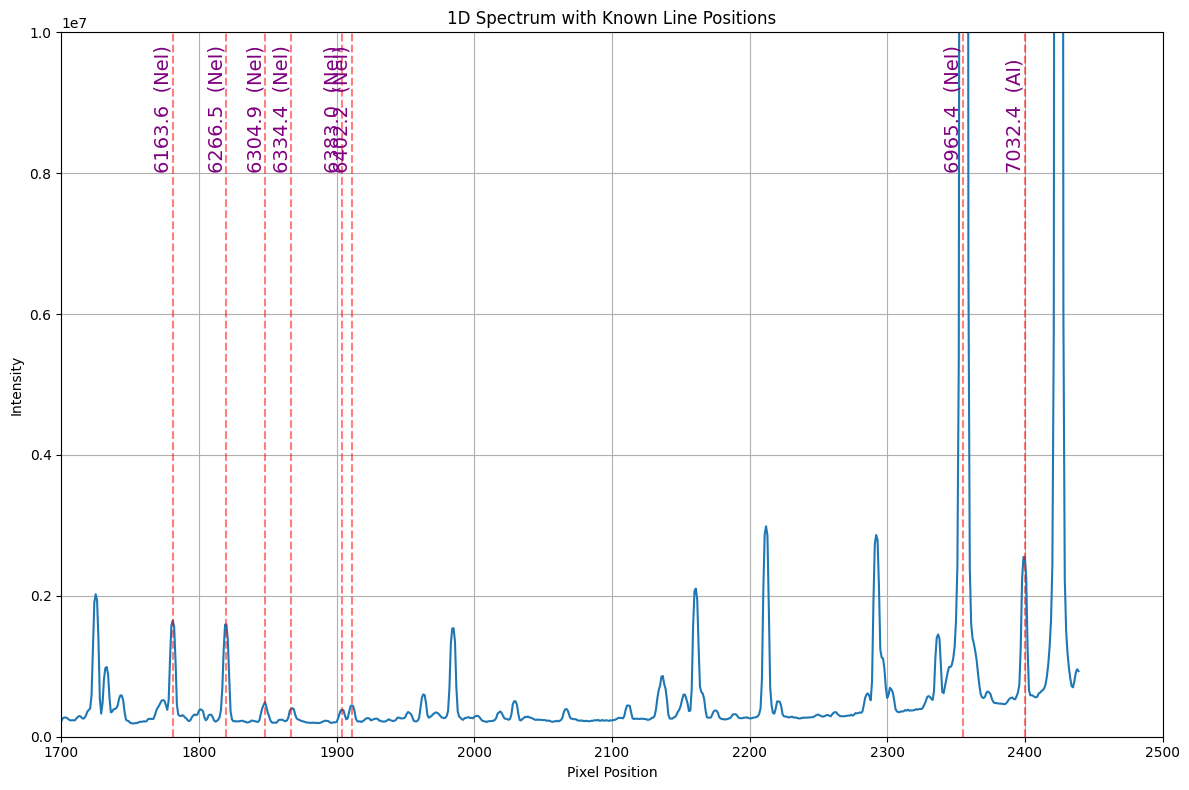

In [ ]:
pixels_solution = np.array([210, 306, 435, 495, 512,540, 643,755,777,808,822,927,955,985,1005,1240,1270,1338,1422,
                            1497,1699, 1699,1781,1820,1848,1867,1904,1911,2355,2400])
wavelength_solution = np.array([3719.935, 3859.400, 4045.450,4131.830, 4158.590, 4199.860, 4348.064,4510.733,
                                4545.080, 4589.900, 4609.560,4764.890, 4806.070,4847.820,4879.900, 5227.300,
                                5269.650,5371.489,5496.210, 5606.732,6074.338,6096.1630,6163.594,6266.495,
                               6304.850,6334.428,6382.991 ,6402.246,6965.4300,7032.4127 ])#7383.980, 7514.651])
wavelength_label = np.array(["FeI", "FeI", "FeI" ,"ArII","ArI", "ArI","FeI", "ArII", "ArII", "AII","AII","AII","AII",
                             "AII","AII","AII", "AII","FeI","FeI","FeI", "AI","NeI","NeI","NeI","NeI","NeI","NeI",
                            "NeI","NeI","AI"])

plot_wavelength_pixel_solution(
    comp_spectrum_1d,
    pixels_solution[-8:],
    wavelength_solution[-8:],
    wavelength_labels= wavelength_label[-8:],
    annotate=True,
    invert_x=False,
    xlim=(1700,2500),
    ylim=(0,10e6)
)


In [ ]:
# Define a polynomial function to fit the data
def polynomial(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

# Fit the polynomial to the data
popt, pcov = curve_fit(polynomial, pixels_solution, wavelength_solution,)
a, b, c, d = popt

# Print out the polynomial coefficients
print("Polynomial coefficients:", popt)


NameError: name 'curve_fit' is not defined

### FAST 1

Using wavelength solution provided

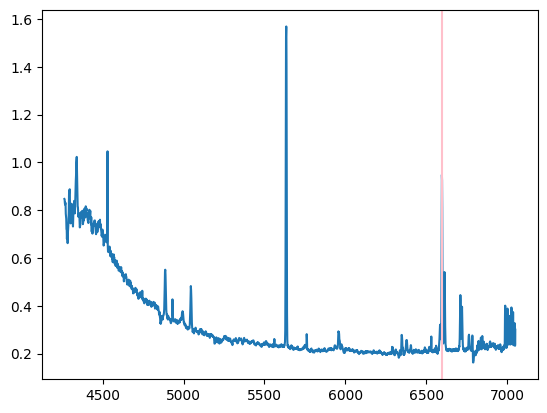

In [29]:
poly = [-1.68082138e-07,  6.07623032e-04, 8.74859881e-01, 3.55690966e+03]
g = np.poly1d(poly)
pixels = np.arange(2720)[600:]
wavelengths = g(pixels)

spectrum_1d_cropped
plt.plot(wavelengths, spectrum_1d_cropped)
plt.axvline(6562 * 1.005, color = 'pink')

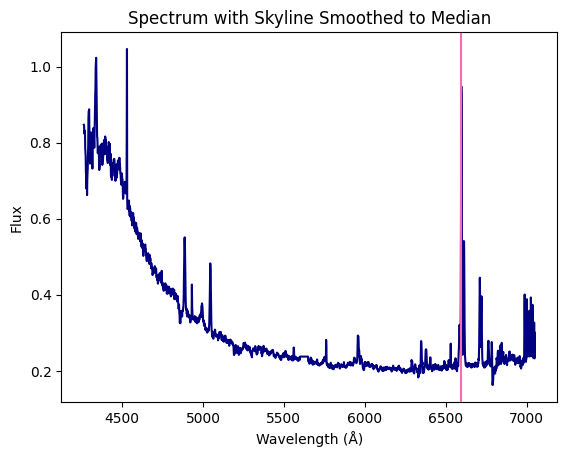

In [36]:

# Define the skyline region
skyline_min = 5600
skyline_max = 5650

# Create a mask for the skyline
skyline_mask = (wavelengths >= skyline_min) & (wavelengths <= skyline_max)

# Create a mask for the nearby good regions (outside skyline)
good_mask = ~skyline_mask

# Find the median of the nearby good region
nearby_median = np.median(spectrum_1d_cropped[good_mask])

# Replace the skyline region with the nearby median
spectrum_1d_cropped[skyline_mask] = nearby_median

# Plot to check
plt.plot(wavelengths, spectrum_1d_cropped, color ='navy')
plt.axvline(6562 * 1.005, color='hotpink')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Spectrum with Skyline Smoothed to Median')
plt.show()


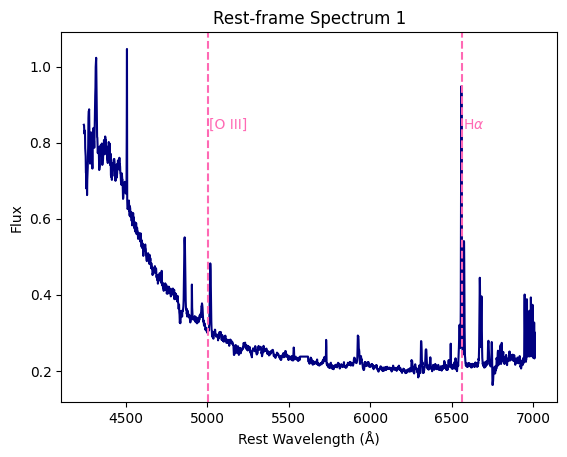

In [37]:
z = 0.005475
wavelengths_rest = wavelengths / (1 + z)


plt.plot(wavelengths_rest, spectrum_1d_cropped, color='navy')
plt.axvline(6562.8, color='hotpink', linestyle='--')  # H-alpha rest-frame
plt.axvline(5006.8, color='hotpink', linestyle='--')  # [O III] rest-frame

# Label them
plt.text(6562.8 + 5, np.max(spectrum_1d_cropped) * 0.8, r'H$\alpha$', color='hotpink')
plt.text(5006.8 + 5, np.max(spectrum_1d_cropped) * 0.8, r'[O III]', color='hotpink')

plt.xlabel('Rest Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Rest-frame Spectrum 1')
plt.show()

to do:
erg cm2 sec etc


In [38]:
V_mag = 11.2 # Apparent mag of NGC4038

# Zero point flux in V-band
F0_V = 3.6e-9

# True flux:
F_V = F0_V * 10**(-0.4 * V_mag)
print(f"V True Flux = {F_V:.3e} erg/s/cm^2/Å")

# Find indices around 5500 Å:
idx_near_5500 = np.where((wavelengths_rest > 5450) & (wavelengths_rest < 5550))[0]

# Mean counts around 5500 Å:
mean_counts_5500 = np.mean(spectrum_1d_cropped[idx_near_5500])
print(f"Average counts near 5500 Å = {mean_counts_5500:.3f}")

# Scaling factor from mean:
scaling_factor = F_V / mean_counts_5500
print(f"Scale factor = {scaling_factor:.3e}")

# Calibrate the full spectrum:
flux_spectrum3 = spectrum_1d_cropped * scaling_factor

# Now in erg/s/cm^2/Å

V-band true flux = 1.19e-13 erg/s/cm^2/Å
Mean counts near 5500 Å = 0.24
Scaling factor = 5.02e-13


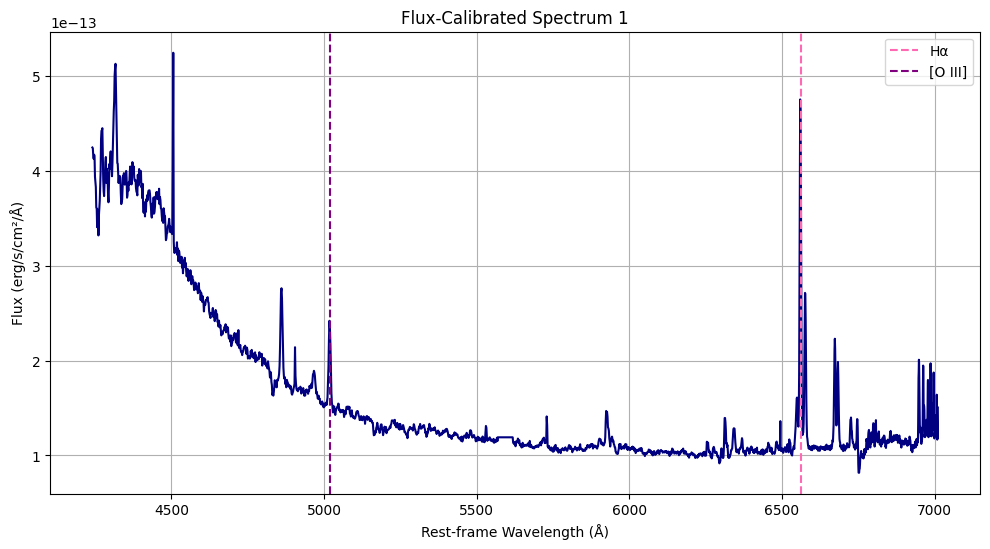

In [39]:
plt.figure(figsize=(12,6))
plt.plot(wavelengths_rest, flux_spectrum1, color='navy')
plt.axvline(6562.8, color='hotpink', linestyle='--', label='Hα')
plt.axvline(5020.8, color='purple', linestyle='--', label='[O III]')

plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.title('Flux-Calibrated Spectrum 1')
plt.legend()
plt.grid(True)
plt.show()



### FAST 2

In [68]:
fast2 = glob.glob(dir+"/0065.NGC4038.fits")
fast3 = glob.glob(dir+"/0064.NGC4038.fits")

science_list2 = glob.glob(dir+"/0065.NGC4038.fits")
science = fits.getdata(science_list2[0])
processed2 = (science - master_bias) / master_flat

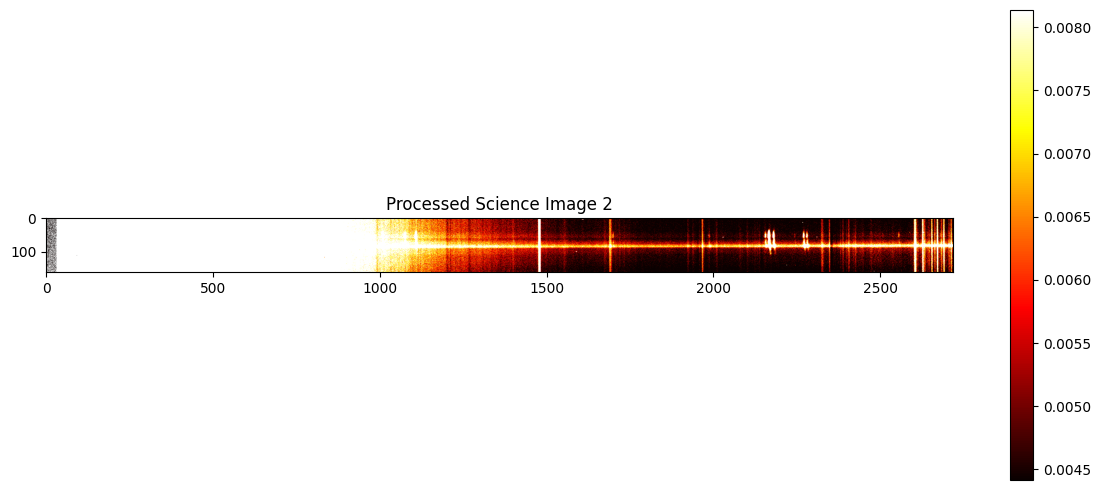

In [69]:
# For processed science image
plt.figure(figsize=(12,5))
plt.imshow(processed2, vmax=np.percentile(processed2, 60),
           vmin=np.percentile(processed2, 20), cmap='hot')
plt.title('Processed Science Image 2')
plt.colorbar()
plt.tight_layout()

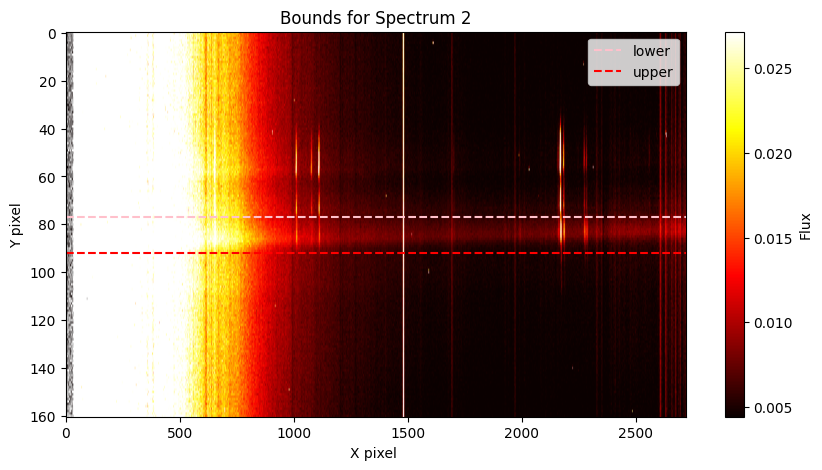

In [70]:
plt.figure(figsize=(10, 5))
plt.imshow(processed2, aspect='auto', cmap='hot',
           vmin=np.percentile(processed2, 20), vmax=np.percentile(processed2, 80))
plt.axhline(77, color='pink', linestyle='--', label='lower')
plt.axhline(92, color='red', linestyle='--', label='upper')
plt.legend()
plt.title("Bounds for Spectrum 2")
plt.xlabel("X pixel ")
plt.ylabel("Y pixel")
plt.colorbar(label='Flux')
plt.show()

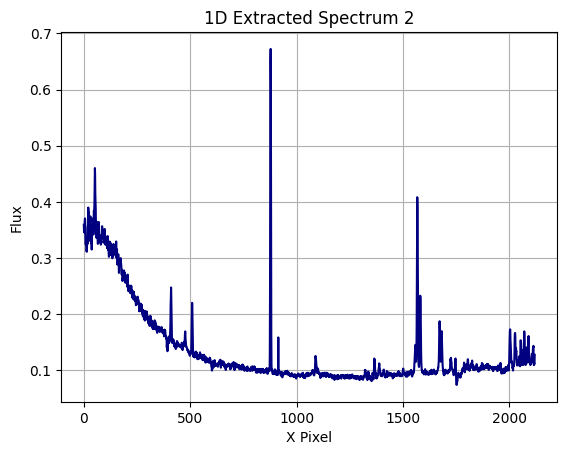

In [71]:
spectrum2_1d_cropped = np.sum(processed2[75:89, 600:], axis=0) # From Jimmy (cropping)

plt.plot(spectrum2_1d_cropped, color = 'navy')
plt.title("1D Extracted Spectrum 2")
plt.xlabel("X Pixel")
plt.ylabel("Flux")
plt.grid()
plt.show()

# strength of h alpha on position of slit


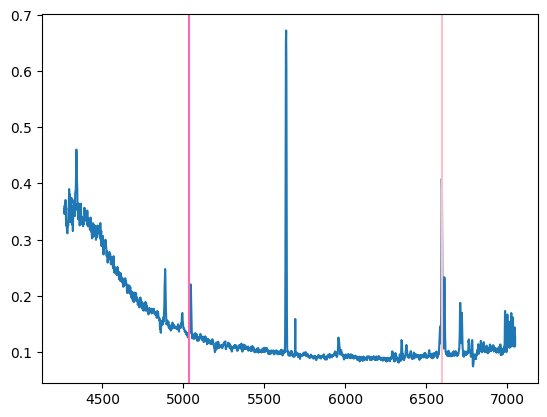

In [72]:
poly = [-1.68082138e-07,  6.07623032e-04, 8.74859881e-01, 3.55690966e+03]
g = np.poly1d(poly)
pixels = np.arange(2720)[600:]
wavelengths = g(pixels)

spectrum2_1d_cropped
plt.plot(wavelengths, spectrum2_1d_cropped)
plt.axvline(6562 * 1.005, color = 'pink')
plt.axvline(5007 * 1.006, color = 'hotpink')


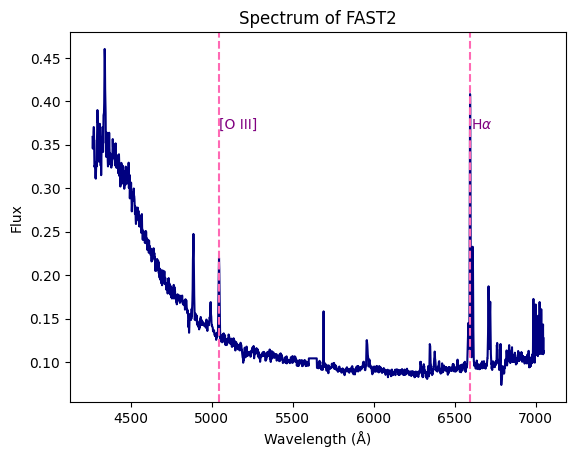

In [73]:

# Define the skyline region
skyline_min = 5600
skyline_max = 5650

# Create a mask for the skyline
skyline_mask = (wavelengths >= skyline_min) & (wavelengths <= skyline_max)

# Create a mask for the nearby good regions (outside skyline)
good_mask = ~skyline_mask

# Find the median of the nearby good region
nearby_median = np.median(spectrum2_1d_cropped[good_mask])

# Replace the skyline region with the nearby median
spectrum2_1d_cropped[skyline_mask] = nearby_median

# Plot to check


plt.plot(wavelengths, spectrum2_1d_cropped, color='navy')

# Plot H-alpha and [O III] lines
plt.axvline(6562 * 1.005, color='hotpink', linestyle='--')
plt.axvline(5007 * 1.007, color='hotpink', linestyle='--')

# Add labels
plt.text(6562 * 1.005 + 5, np.max(spectrum2_1d_cropped) * 0.8, r'H$\alpha$', color='purple')
plt.text(5007 * 1.007 + 5, np.max(spectrum2_1d_cropped) * 0.8, r'[O III]', color='purple')

plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Spectrum of FAST2')
plt.show()




In [74]:
V_mag = 11.2 # Apparent mag of NGC4038

# Zero point flux in V-band
F0_V = 3.6e-9

# True flux:
F_V = F0_V * 10**(-0.4 * V_mag)
print(f"V True Flux = {F_V:.3e} erg/s/cm^2/Å")

# Find indices around 5500 Å:
idx_near_5500 = np.where((wavelengths_rest > 5450) & (wavelengths_rest < 5550))[0]

# Mean counts around 5500 Å:
mean_counts_5500 = np.mean(spectrum2_1d_cropped[idx_near_5500])
print(f"Average counts near 5500 Å = {mean_counts_5500:.3f}")

# Scaling factor from mean:
scaling_factor = F_V / mean_counts_5500
print(f"Scale factor = {scaling_factor:.3e}")

# Calibrate the full spectrum:
flux_spectrum3 = spectrum2_1d_cropped * scaling_factor

# Now in erg/s/cm^2/Å


V-band true flux = 1.19e-13 erg/s/cm^2/Å
Mean counts near 5500 Å = 0.10
Scaling factor = 1.18e-12


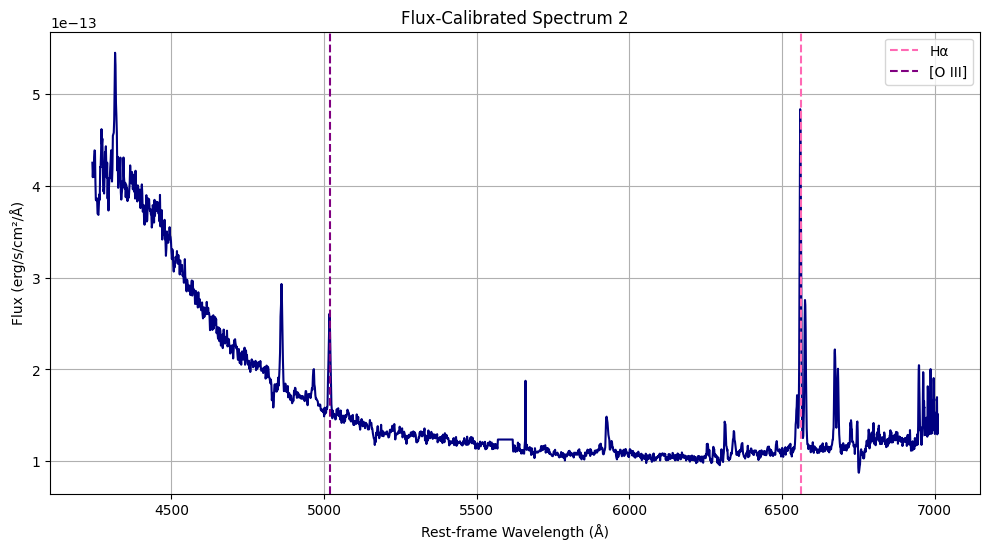

In [76]:
plt.figure(figsize=(12,6))
plt.plot(wavelengths_rest, flux_spectrum2, color='navy')
plt.axvline(6562.8, color='hotpink', linestyle='--', label='Hα')
plt.axvline(5020.8, color='purple', linestyle='--', label='[O III]')

plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.title('Flux-Calibrated Spectrum 2')
plt.legend()
plt.grid(True)
plt.show()

### FAST 3

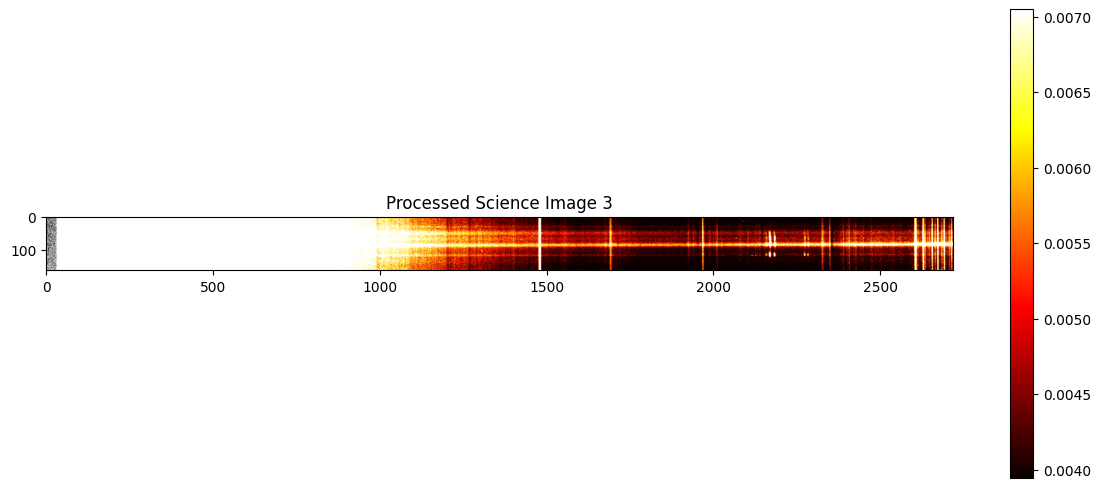

In [9]:
science_list3 = glob.glob(dir+"/0064.NGC4038.fits")
science = fits.getdata(science_list3[0])
processed3 = (science - master_bias) / master_flat

plt.figure(figsize=(12,5))
plt.imshow(processed3, vmax=np.percentile(processed3, 60),
           vmin=np.percentile(processed3, 20), cmap='hot')
plt.title('Processed Science Image 3')
plt.colorbar()
plt.tight_layout()

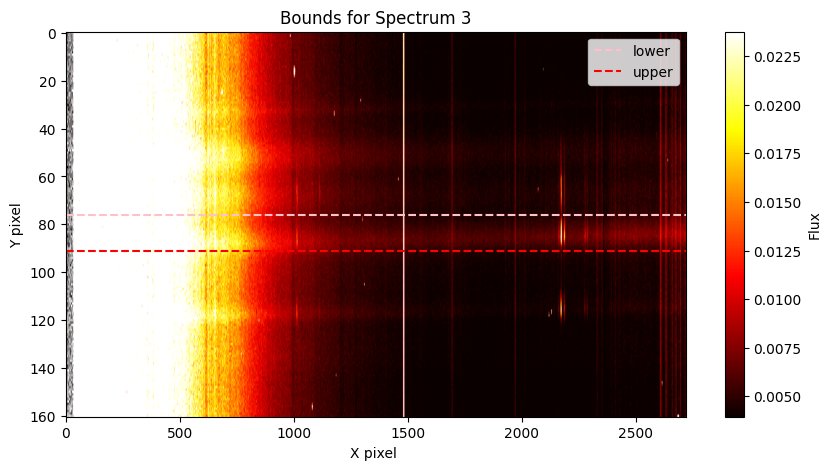

In [10]:
plt.figure(figsize=(10, 5))
plt.imshow(processed3, aspect='auto', cmap='hot',
           vmin=np.percentile(processed3, 20), vmax=np.percentile(processed3, 80))
plt.axhline(76, color='pink', linestyle='--', label='lower')
plt.axhline(91, color='red', linestyle='--', label='upper')
plt.legend()
plt.title("Bounds for Spectrum 3")
plt.xlabel("X pixel ")
plt.ylabel("Y pixel")
plt.colorbar(label='Flux')
plt.show()

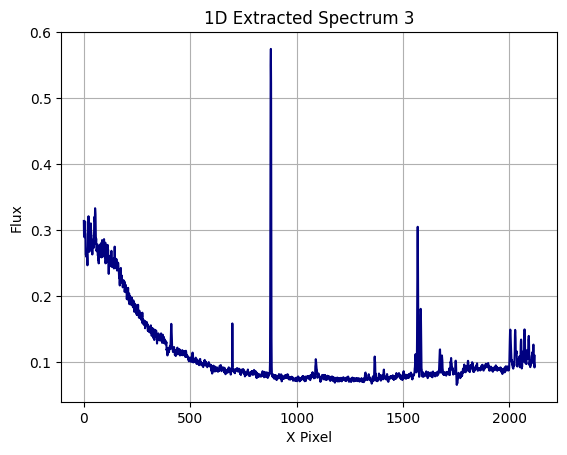

In [11]:
spectrum3_1d_cropped = np.sum(processed3[75:89, 600:], axis=0) # From Jimmy (cropping)

plt.plot(spectrum3_1d_cropped, color = 'navy')
plt.title("1D Extracted Spectrum 3")
plt.xlabel("X Pixel")
plt.ylabel("Flux")
plt.grid()
plt.show()


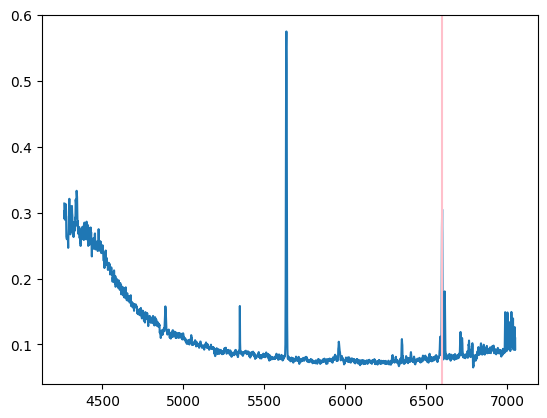

In [12]:
poly = [-1.68082138e-07,  6.07623032e-04, 8.74859881e-01, 3.55690966e+03]
g = np.poly1d(poly)
pixels = np.arange(2720)[600:]
wavelengths = g(pixels)

spectrum3_1d_cropped
plt.plot(wavelengths, spectrum3_1d_cropped)
plt.axvline(6562 * 1.005, color = 'pink')
#plt.axvline(5007 * 1.006, color = 'hotpink')



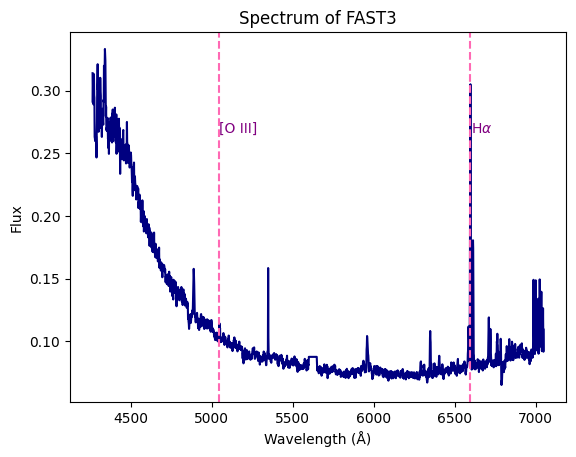

In [13]:
# Define the skyline region
skyline_min = 5600
skyline_max = 5650

# Create a mask for the skyline
skyline_mask = (wavelengths >= skyline_min) & (wavelengths <= skyline_max)
good_mask = ~skyline_mask

nearby_median = np.median(spectrum3_1d_cropped[good_mask])

# Replace the skyline region with the nearby median
spectrum3_1d_cropped[skyline_mask] = nearby_median


plt.plot(wavelengths, spectrum3_1d_cropped, color='navy')

# Plot H-alpha and [O III] lines
plt.axvline(6562 * 1.005, color='hotpink', linestyle='--')
plt.axvline(5007 * 1.007, color='hotpink', linestyle='--')

# Add labels
plt.text(6562 * 1.005 + 5, np.max(spectrum3_1d_cropped) * 0.8, r'H$\alpha$', color='purple')
plt.text(5007 * 1.007 + 5, np.max(spectrum3_1d_cropped) * 0.8, r'[O III]', color='purple')

plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Spectrum of FAST3')
plt.show()




In [19]:
V_mag = 11.2 # Apparent mag of NGC4038

# Zero point flux in V-band
F0_V = 3.6e-9

# True flux:
F_V = F0_V * 10**(-0.4 * V_mag)
print(f"V True Flux = {F_V:.3e} erg/s/cm^2/Å")

# Find indices around 5500 Å:
idx_near_5500 = np.where((wavelengths_rest > 5450) & (wavelengths_rest < 5550))[0]

# Mean counts around 5500 Å:
mean_counts_5500 = np.mean(spectrum3_1d_cropped[idx_near_5500])
print(f"Average counts near 5500 Å = {mean_counts_5500:.3f}")

# Scaling factor from mean:
scaling_factor = F_V / mean_counts_5500
print(f"Scale factor = {scaling_factor:.3e}")

# Calibrate the full spectrum:
flux_spectrum3 = spectrum3_1d_cropped * scaling_factor

# Now in erg/s/cm^2/Å

V True Flux = 1.192e-13 erg/s/cm^2/Å
Average counts near 5500 Å = 0.082
Scale factor = 1.462e-12


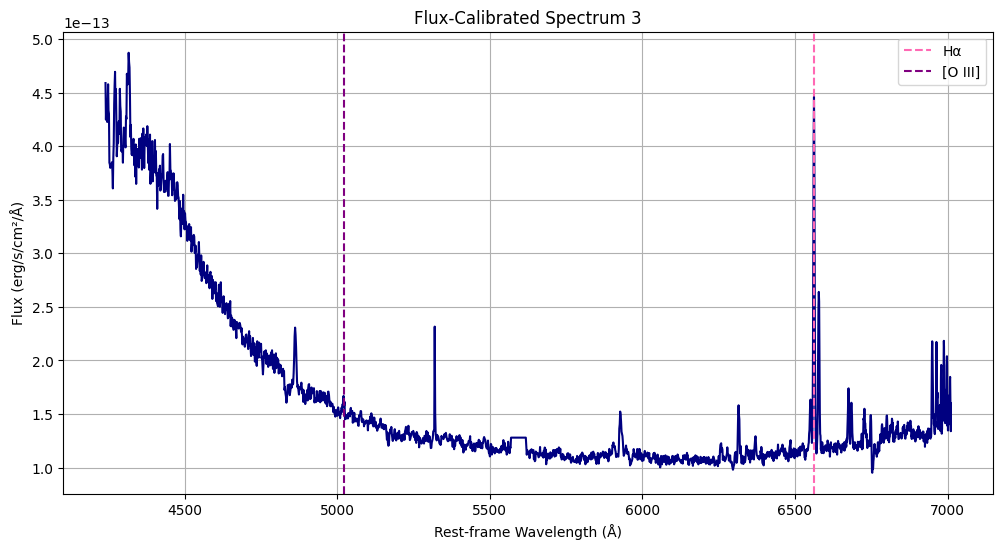

In [20]:
plt.figure(figsize=(12,6))
plt.plot(wavelengths_rest, flux_spectrum3, color='navy')
plt.axvline(6562.8, color='hotpink', linestyle='--', label='Hα')
plt.axvline(5020.8, color='purple', linestyle='--', label='[O III]')

plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Flux (erg/s/cm²/Å)')
plt.title('Flux-Calibrated Spectrum 3')
plt.legend()
plt.grid(True)
plt.show()

### Examining difference in Flux in H Alpha Line:

Spectrum 3:

In [67]:
# Wavelength window around Hα
ha_min = 6550
ha_max = 6570

# Find indices within the Hα window
ha_mask = (wavelengths_rest >= ha_min) & (wavelengths_rest <= ha_max)

# Regions before and after Hα
cont_mask = ((wavelengths_rest >= 6500) & (wavelengths_rest <= 6570)) | \
            ((wavelengths_rest >= 6570) & (wavelengths_rest <= 6600))

# Estimate flux in surrouding regions by using median:
continuum_level = np.median(flux_spectrum3[cont_mask])

# Subtract from Hα:
line_flux = flux_spectrum3[ha_mask] - continuum_level

# Integrate the line (should only be part above median)
ha_flux = np.trapz(line_flux, wavelengths_rest[ha_mask])

print(f"Hα line flux = {ha_flux:.2e} erg/s/cm²")


Hα line flux = 1.80e-12 erg/s/cm²


In [68]:
# Constants
c = 3e5  # km/s
H0 = 70  # km/s/Mpc
Mpc_to_cm = 3.086e24  # cm/Mpc

# NGC 4038/4039 redshift
z = 0.005475

# Luminosity distance
d_L_Mpc = (c * z) / H0  # in Mpc
d_L_cm = d_L_Mpc * Mpc_to_cm  # in cm

print(f"Luminosity distance = {d_L_cm:.2e} cm")


Luminosity distance = 7.24e+25 cm


In [69]:
f_Ha = ha_flux  # Measured flux

# Calculate luminosity using flux relation:
L_Ha = 4 * np.pi * d_L_cm**2 * f_Ha  # erg/s

print(f"Hα luminosity = {L_Ha:.2e} erg/s")

Hα luminosity = 1.18e+41 erg/s


In [70]:
# Calculate star formation rate using Kennicutt
SFR = L_Ha / 1.26e41
print(f"Estimated SFR = {SFR:.2f} M☉/yr")

Estimated SFR = 0.94 M☉/yr


Spectrum 1

In [71]:
# Wavelength window around Hα
ha_min = 6550
ha_max = 6570

# Find indices within the Hα window
ha_mask = (wavelengths_rest >= ha_min) & (wavelengths_rest <= ha_max)

# Regions before and after Hα
cont_mask = ((wavelengths_rest >= 6500) & (wavelengths_rest <= 6570)) | \
            ((wavelengths_rest >= 6570) & (wavelengths_rest <= 6600))

# Estimate flux in surrouding regions by using median:
continuum_level = np.median(flux_spectrum1[cont_mask])

# Subtract from Hα:
line_flux = flux_spectrum1[ha_mask] - continuum_level

# Integrate the line (should only be part above median)
ha_flux = np.trapz(line_flux, wavelengths_rest[ha_mask])

print(f"Hα line flux = {ha_flux:.2e} erg/s/cm²")

Hα line flux = 2.31e-12 erg/s/cm²


In [72]:
# Constants
c = 3e5  # km/s
H0 = 70  # km/s/Mpc
Mpc_to_cm = 3.086e24  # cm/Mpc

# NGC 4038/4039 redshift
z = 0.005475

# Luminosity distance
d_L_Mpc = (c * z) / H0  # in Mpc
d_L_cm = d_L_Mpc * Mpc_to_cm  # in cm

print(f"Luminosity distance = {d_L_cm:.2e} cm")

Luminosity distance = 7.24e+25 cm


In [73]:
f_Ha = ha_flux  # Measured flux

# Calculate luminosity using flux relation:
L_Ha = 4 * np.pi * d_L_cm**2 * f_Ha  # erg/s

print(f"Hα luminosity = {L_Ha:.2e} erg/s")


Hα luminosity = 1.52e+41 erg/s


In [74]:
# Calculate star formation rate using Kennicutt

SFR = L_Ha / 1.26e41
print(f"Estimated SFR = {SFR:.2f} M☉/yr")

Estimated SFR = 1.21 M☉/yr
